# Dataset from Roboflow

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/Deep Learning for Computer Vision/7.Segmentation/Yolo For Segmentation/Project_ Fine Tuning YoloV8 Segmentation

/content/drive/MyDrive/Deep Learning for Computer Vision/7.Segmentation/Yolo For Segmentation/Project_ Fine Tuning YoloV8 Segmentation


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="nOGUiSTbKGxLtUpsmE9d")
project = rf.workspace("aegis-8nzeo").project("brain-tumor-segmentation-wltzi")
version = project.version(1)
dataset = version.download("yolov12")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 107.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Brain-Tumor-Segmentation-1 in yolov12:: 100%|██████████| 2194/2194 [00:20<00:00, 105.74it/s]


# Setup

Pip install `ultralytics` and [dependencies](https://github.com/ultralytics/ultralytics/blob/main/pyproject.toml) and check software and hardware.

In [4]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.7/112.6 GB disk)


# 1. Train

In [5]:
ls

 Brain-Tumor-Segmentation-1/                 yolov8n-seg.pt
 instance-segmentation-object-tracking.avi   YOLOv8_Segmentation.ipynb
 traffictrim.mp4                            'Yolov8 segmentation.py'


In [ ]:
#https://docs.ultralytics.com/models/yolov8/#supported-tasks-and-modes
#https://github.com/ultralytics/ultralytics

In [6]:
# Train YOLOv8n on COCO8 for 100 epochs
!yolo task= segment mode= train data=Brain-Tumor-Segmentation-1/data.yaml model=yolov8s-seg.pt epochs=30 imgsz=640

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Brain-Tumor-Segmentation-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

In [8]:
ls

 Brain-Tumor-Segmentation-1/                 yolov8n-seg.pt
 instance-segmentation-object-tracking.avi   YOLOv8_Segmentation.ipynb
 runs/                                      'Yolov8 segmentation.py'
 traffictrim.mp4                             yolov8s-seg.pt
 yolo26n.pt


## Add five epochs

In [9]:
# Train YOLOv8n on COCO8 for 100 epochs
!yolo task= segment mode=train data=Brain-Tumor-Segmentation-1/data.yaml model=runs/segment/train/weights/best.pt epochs=5 imgsz=640

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Brain-Tumor-Segmentation-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/segment/train/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

In [10]:
ls

 Brain-Tumor-Segmentation-1/                 yolov8n-seg.pt
 instance-segmentation-object-tracking.avi   YOLOv8_Segmentation.ipynb
 runs/                                      'Yolov8 segmentation.py'
 traffictrim.mp4                             yolov8s-seg.pt
 yolo26n.pt


# 2. Predict

In [12]:
!yolo task=segment mode=predict model=runs/segment/train/weights/best.pt imgsz=640 conf=0.5 source=Brain-Tumor-Segmentation-1/test/images

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs

image 1/46 /content/drive/MyDrive/Deep Learning for Computer Vision/7.Segmentation/Yolo For Segmentation/Project_ Fine Tuning YoloV8 Segmentation/Brain-Tumor-Segmentation-1/test/images/y100_jpg.rf.f566b68cf4231c96939bcfac9b538099.jpg: 640x640 1 object, 20.9ms
image 2/46 /content/drive/MyDrive/Deep Learning for Computer Vision/7.Segmentation/Yolo For Segmentation/Project_ Fine Tuning YoloV8 Segmentation/Brain-Tumor-Segmentation-1/test/images/y137_jpg.rf.ecc5249c2fe75e67d3c4f27885febcf5.jpg: 640x640 1 object, 20.8ms
image 3/46 /content/drive/MyDrive/Deep Learning for Computer Vision/7.Segmentation/Yolo For Segmentation/Project_ Fine Tuning YoloV8 Segmentation/Brain-Tumor-Segmentation-1/test/images/y145_jpg.rf.c02bff98489884fa2d2012f9821938de.jpg: 640x640 2 objects, 20.7ms
image 4/46 /content/drive/MyDrive/Deep Learning

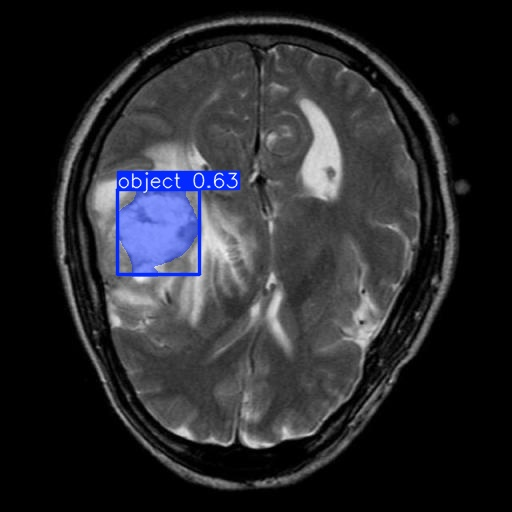

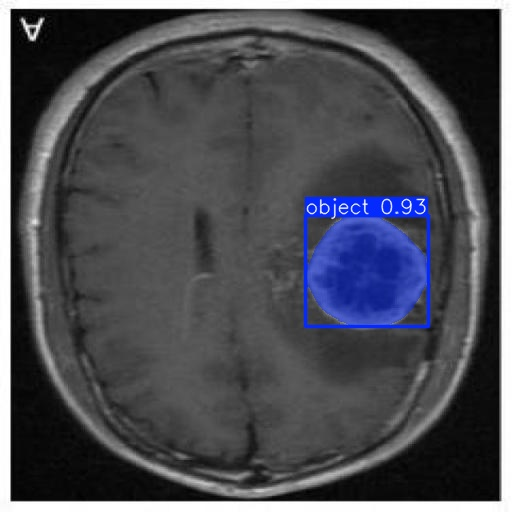

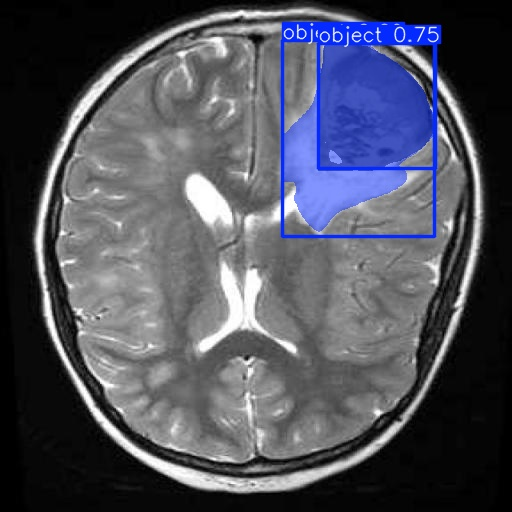

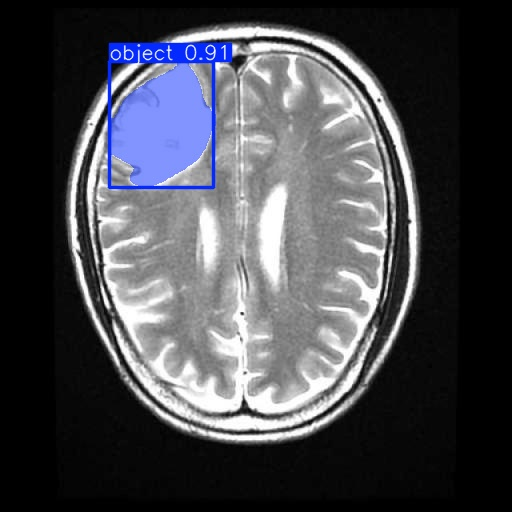

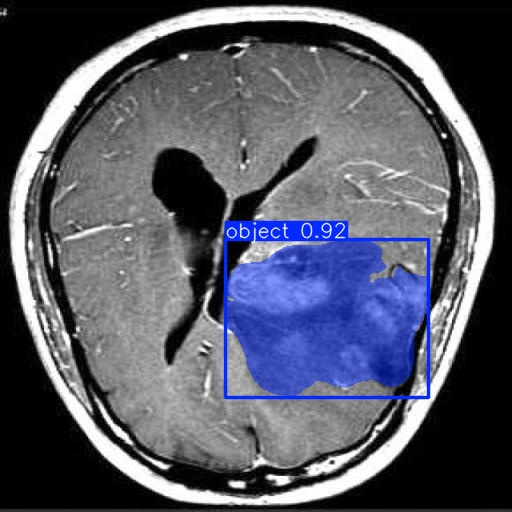

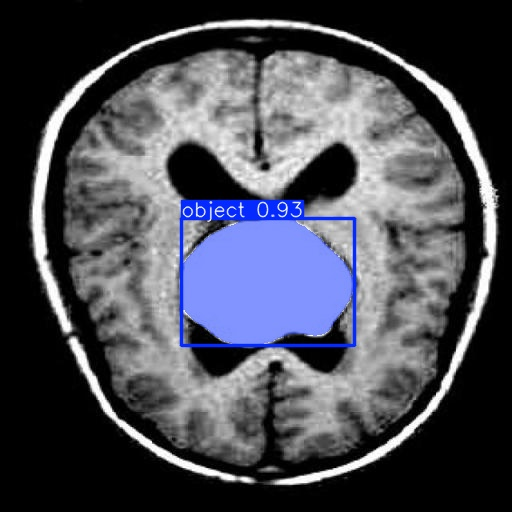

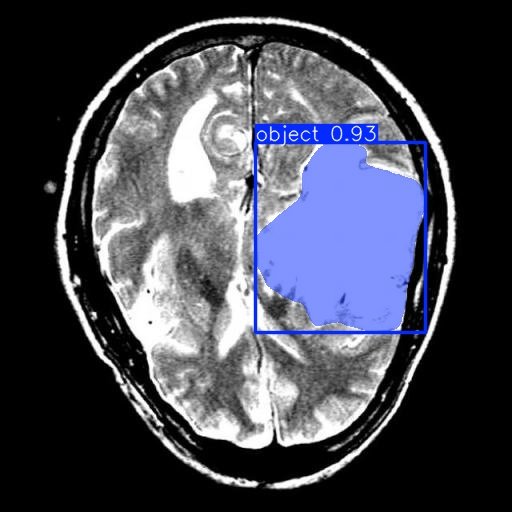

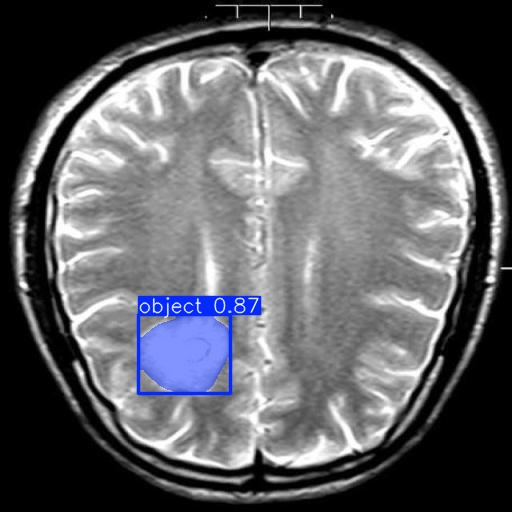

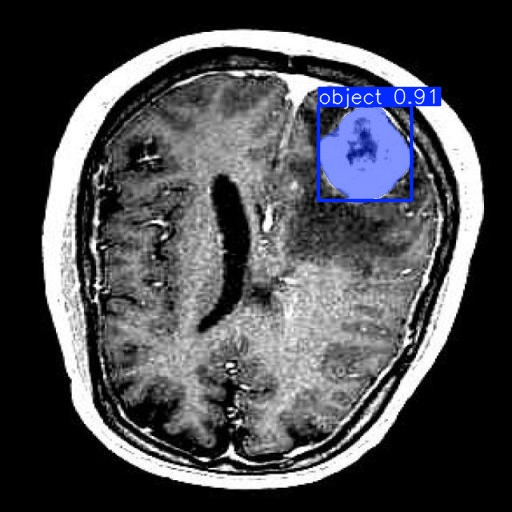

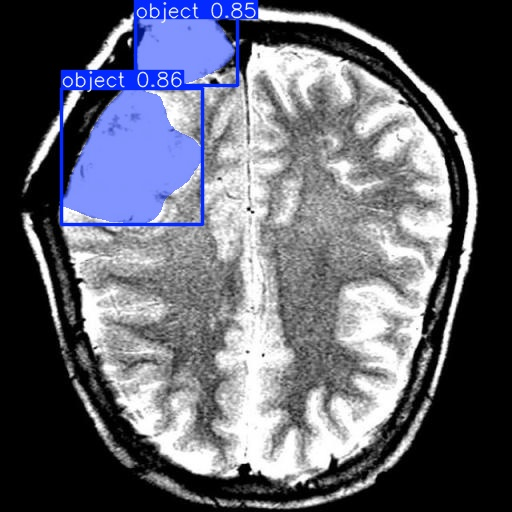

In [13]:
# Display inference on ALL test images
import glob
from IPython.display import Image, display

for imageName in glob.glob("runs/segment/predict/*.jpg")[:10]: #assuming JPG

    print("\n")
    display(Image(filename=imageName))

